# 13 강건성 — 대조군 명세별 β7 안정성

- 정답을 하나 고르는 게 아니라, 대조군 정의를 여러 개 만들어서 결과가 얼마나 흔들리는지 보여주고, 그중 하나를 주 분석(main specification)으로, 나머지를 강건성 검증(robustness check)으로 보고한다.

In [1]:
## 0. 공통 준비 (이미 되어 있으면 스킵 가능)
import pandas as pd, numpy as np, statsmodels.api as sm, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

PRE, POST = [202601,202602,202603,202604], [202605,202606]

main = pd.read_csv('../data/ABP_CONTEST_DATA.csv', dtype={'GENDER_CD': str})
main = main[main.GENDER_CD != 'x'].copy()    # ← 법인 제외 (신규 추가)
main['grp']     = np.where(main.TP_BUZ_NM == '대형할인점', 'C', 'T')
main['post']    = main.STRD_YYMM.isin(POST).astype(int)
main['incheon'] = (main.SIDO_NM == '인천광역시').astype(int)
main['region']  = main.SIDO_NM + ' ' + main.CCG_NM

def region_mask(d, pairs):
    m = pd.Series(False, index=d.index)
    for sido, ccg in pairs:
        s = d.SIDO_NM.str.contains(sido)
        m |= s if ccg is None else (s & (d.CCG_NM == ccg))
    return m

# 표1 (5월 이후 시행 — 완전 제외 대상)
## 수정된 EXCLUDE / CONFIRMED_BLEED
EXCLUDE = [
    ('강원', '속초시'), ('경기', '광명시'), ('경기', '남양주시'), ('경기', '동두천시'),
    ('경기', '안성시'), ('경기', '이천시'), ('경남', '남해군'), ('경북', '상주시'),
    ('서울', None), ('충북', '괴산군'),
    # ('부산', None) 제거 — 근거(1주일 지정 가맹점 이벤트)가 광역시 전체 제외를 정당화하기엔 너무 약함
]

CONFIRMED_BLEED = [
    ('강원', '강릉시'), ('강원', '태백시'), ('경북', '영주시'),
    ('충남', '계룡시'), ('울산', None),('경기','이천시'),
    ('부산', '중구'),   # 신규 추가 — 종료일 미명시, 2월부터 지속 → POST까지 이어진다고 보수적 가정
]

PLACEBO = [
    ('강원', '강릉시'), ('강원', '태백시'), ('강원', '평창군'),
    ('경기', '용인시'), ('경남', '양산시'), ('경북', '영주시'),
    ('광주', '광산구'), ('부산', '중구'), ('울산', None),
    ('전남', '강진군'), ('전남', '광양시'), ('전남', '나주시'),
    ('전남', '보성군'), ('전남', '영암군'),
    ('전북', '김제시'), ('전북', '순창군'), ('제주', None),
    ('충남', '계룡시'), ('충남', '논산시'),
    ('충북', '영동군'), ('충북', '청주시'),
]

def cells(d):
    c = d.groupby(['region', 'TP_BUZ_NM', 'STRD_YYMM', 'incheon', 'post', 'grp'], as_index=False).amt.sum()
    c['y']   = np.log(c.amt)
    c['pi']  = c.post * c.incheon
    c['pit'] = c.pi * (c.grp == 'T')
    c['ri']  = c.region + '|' + c.TP_BUZ_NM
    c['mi']  = c.STRD_YYMM.astype(str) + '|' + c.TP_BUZ_NM
    return c

def demean2(X, f1, f2, tol=1e-9, maxit=500):
    for _ in range(maxit):
        X0 = X
        X = X - X.groupby(f1).transform('mean')
        X = X - X.groupby(f2).transform('mean')
        if (X - X0).abs().max().max() < tol:
            break
    return X

def fe_reg(c, xs):
    Y = demean2(c[['y'] + xs].astype(float), c.ri, c.mi)
    m = sm.OLS(Y.y, Y[xs]).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(c.region)[0]})
    return pd.DataFrame({'coef': m.params, 'se': m.bse, 'p': m.pvalues})

def geo_samples(d):
    # '수도권만'은 셀 수 대비 FE가 과다해 반복적으로 비식별 → 제외
    return {'전국 전체': d, '부산·경남 제외': d[~d.SIDO_NM.isin(['부산광역시', '경상남도'])]}

In [2]:
## 1. ①②③ 대조군 명세 정의
main['spec_baseline']     = pd.Series(True, index=main.index)
main['spec_main_strict']  = ~region_mask(main, EXCLUDE + CONFIRMED_BLEED) | (main.incheon == 1)
main['spec_conservative'] = ~region_mask(main, EXCLUDE + PLACEBO)         | (main.incheon == 1)
SPECS = {
    '① Baseline':               'spec_baseline',
    '② Main (표1 + 확정오염 제외, STRICT)':    'spec_main_strict',
    '③ Conservative (표1 + 표2 전체 제외)':    'spec_conservative',
}

In [3]:
## 2. 법인제외 전체(내국인+외국인) / 내국인 × ①②③ × 대조군 범위(전국/부산경남제외) 전부 돌려서 비교표 생성
indiv = main[main.GENDER_CD.isin(['1', '2'])]

rows = []
for pop_label, pop_df in [('법인제외 전체(내국인+외국인)', main), ('내국인만', indiv)]:
    for spec_label, spec_col in SPECS.items():
        d0 = pop_df[pop_df[spec_col]]
        for geo_label, d in geo_samples(d0).items():
            c = cells(d)
            n_incheon_region = c[c.incheon == 1].region.nunique()
            n_ctrl_region    = c[c.incheon == 0].region.nunique()
            if c[['pi','pit']].std().min() < 1e-8 or n_ctrl_region < 5:
                rows.append({'인구': pop_label, '명세': spec_label, '대조군범위': geo_label,
                             'n셀': len(c), '대조군 시군구수': n_ctrl_region,
                             'β7(%)': np.nan, 'p': np.nan, '비고': '식별 불가(표본 부족)'})
                continue
            r = fe_reg(c, ['pi', 'pit'])
            rows.append({'인구': pop_label, '명세': spec_label, '대조군범위': geo_label,
                         'n셀': len(c), '대조군 시군구수': n_ctrl_region,
                         'β7(%)': np.expm1(r.coef.pit) * 100, 'p': r.p.pit, '비고': ''})

result = pd.DataFrame(rows).set_index(['인구', '명세', '대조군범위'])
result

n셀  대조군 시군구수  \
인구               명세                             대조군범위                       
법인제외 전체(내국인+외국인) ① Baseline                     전국 전체     14119       245   
                                                부산·경남 제외  11862       207   
                 ② Main (표1 + 확정오염 제외, STRICT)  전국 전체     11860       206   
                                                부산·경남 제외   9668       169   
                 ③ Conservative (표1 + 표2 전체 제외) 전국 전체     11521       200   
                                                부산·경남 제외   9329       163   
내국인만             ① Baseline                     전국 전체     14114       245   
                                                부산·경남 제외  11857       207   
                 ② Main (표1 + 확정오염 제외, STRICT)  전국 전체     11855       206   
                                                부산·경남 제외   9663       169   
                 ③ Conservative (표1 + 표2 전체 제외) 전국 전체     11521       200   
                                                부산·경남 제외   9329       163   

                                                          β7(%)    p 비고  
인구               명세                             대조군범위                    
법인제외 전체(내국인+외국인) ① Baseline                     전국 전체    -10.20 0.09     
                                                부산·경남 제외 -10.58 0.08     
                 ② Main (표1 + 확정오염 제외, STRICT)  전국 전체    -11.36 0.07     
                                                부산·경남 제외 -11.95 0.05     
                 ③ Conservative (표1 + 표2 전체 제외) 전국 전체    -11.63 0.06     
                                                부산·경남 제외 -12.30 0.05     
내국인만             ① Baseline                     전국 전체    -10.60 0.08     
                                                부산·경남 제외 -11.00 0.07     
                 ② Main (표1 + 확정오염 제외, STRICT)  전국 전체    -11.78 0.05     
                                                부산·경남 제외 -12.40 0.04     
                 ③ Conservative (표1 + 표2 전체 제외) 전국 전체    -12.07 0.05     
                                                부산·경남 제외 -12.78 0.04

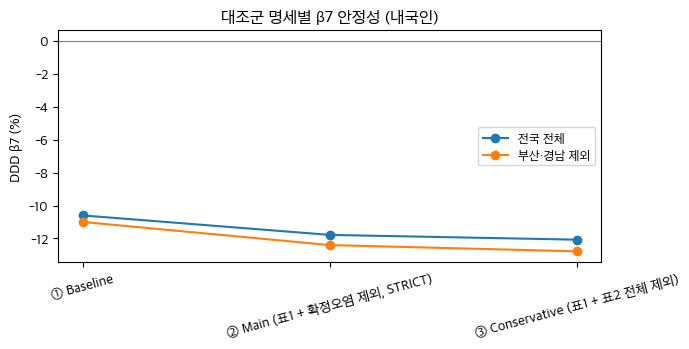

In [4]:
## 3. 명세 간 안정성 시각화 (내국인 기준)
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
OUT = Path('../outputs/13_robust_spec'); OUT.mkdir(parents=True, exist_ok=True)   # 그림 저장 폴더
mpl.rcParams['font.family'] = [f for f in ['Apple SD Gothic Neo', 'Malgun Gothic'] if f in {x.name for x in mpl.font_manager.fontManager.ttflist}]   # macOS / Windows 중 설치된 것
mpl.rcParams['axes.unicode_minus'] = False

sub = result.loc['내국인만'].dropna(subset=['β7(%)']).reset_index()
fig, ax = plt.subplots(figsize=(7, 3.6))
for i, geo in enumerate(sub['대조군범위'].unique()):
    s = sub[sub['대조군범위'] == geo]
    ax.plot(s['명세'], s['β7(%)'], marker='o', label=geo)
ax.axhline(0, color='grey', lw=0.8)
ax.set_ylabel('DDD β7 (%)'); ax.set_title('대조군 명세별 β7 안정성 (내국인)')
ax.tick_params(axis='x', rotation=15); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(OUT / '03_beta7_by_spec.png', dpi=200, bbox_inches='tight'); plt.show()

In [5]:
# 재현성 체크
print(main.shape, main.incheon.sum(), main.GENDER_CD.value_counts())
print((main['spec_baseline']).sum(), len(main))  # baseline이 전체 행수와 같아야 정상

(229413, 16) 9115 GENDER_CD
1    80554
2    78681
3    70178
Name: count, dtype: int64
229413 229413


In [6]:
## 0. 준비 — main, region_mask, cells, demean2, fe_reg 는 이전과 동일 (이미 있으면 스킵)
import pandas as pd, numpy as np, statsmodels.api as sm, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

def region_mask(d, pairs):
    m = pd.Series(False, index=d.index)
    for sido, ccg in pairs:
        s = d.SIDO_NM.str.contains(sido)
        m |= s if ccg is None else (s & (d.CCG_NM == ccg))
    return m

def cells(d):
    c = d.groupby(['region', 'TP_BUZ_NM', 'STRD_YYMM', 'incheon', 'post', 'grp'], as_index=False).amt.sum()
    c['y']   = np.log(c.amt)
    c['pi']  = c.post * c.incheon
    c['pit'] = c.pi * (c.grp == 'T')
    c['ri']  = c.region + '|' + c.TP_BUZ_NM
    c['mi']  = c.STRD_YYMM.astype(str) + '|' + c.TP_BUZ_NM
    return c

def demean2(X, f1, f2, tol=1e-9, maxit=500):
    for _ in range(maxit):
        X0 = X
        X = X - X.groupby(f1).transform('mean')
        X = X - X.groupby(f2).transform('mean')
        if (X - X0).abs().max().max() < tol:
            break
    return X

def fe_reg(c, xs):
    Y = demean2(c[['y'] + xs].astype(float), c.ri, c.mi)
    m = sm.OLS(Y.y, Y[xs]).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(c.region)[0]})
    return pd.DataFrame({'coef': m.params, 'se': m.bse, 'p': m.pvalues})

def rate(d):
    return (d[d.post == 1].amt.sum() / 2) / (d[d.post == 0].amt.sum() / 4) * 100 - 100

def ddd(inc, ctrl):
    T = lambda d: d[d.grp == 'T']; C = lambda d: d[d.grp == 'C']
    r = dict(인천T=rate(T(inc)), 대조T=rate(T(ctrl)), 인천C=rate(C(inc)), 대조C=rate(C(ctrl)))
    r['DiD_T'] = r['인천T'] - r['대조T']; r['DiD_C'] = r['인천C'] - r['대조C']; r['DSI'] = r['DiD_T'] - r['DiD_C']
    return r

In [7]:
## 1. A/B/C/D 4단계 배제 리스트 정의
EXCLUDE_CORE = [
    ('강원','속초시'), ('경기','광명시'), ('경기','남양주시'), ('경기','동두천시'),
    ('경기','안성시'), ('경기','이천시'), ('경남','남해군'), ('경북','상주시'),
    ('충북','괴산군'),
]
SEOUL = [('서울', None)]

BLEED_INTO_POST = [   # 표2 - POST(5~6월)까지 새는 유형
    ('강원','강릉시'), ('강원','태백시'), ('경북','영주시'),
    ('충남','계룡시'), ('울산', None), ('부산','중구'),
]
PRE_ONLY_SPIKE = [     # 표2 - PRE에서만 반짝하고 끝난 유형
    ('강원','평창군'), ('경기','용인시'), ('경남','양산시'), ('광주','광산구'),
    ('전남','광양시'), ('전남','나주시'), ('전남','영암군'), ('전북','김제시'),
    ('제주', None), ('충남','논산시'), ('충북','청주시'),
]

SPEC_LISTS = {
    'A. Core만':                        EXCLUDE_CORE,
    'B. Core+서울':                      EXCLUDE_CORE + SEOUL,
    'C. Core+서울+POST오염':              EXCLUDE_CORE + SEOUL + BLEED_INTO_POST,
    'D. Core+서울+POST오염+PRE오염(최종)':  EXCLUDE_CORE + SEOUL + BLEED_INTO_POST + PRE_ONLY_SPIKE,
}

for label, lst in SPEC_LISTS.items():
    col = 'spec_' + label[0]   # A/B/C/D
    main[col] = ~region_mask(main, lst) | (main.incheon == 1)

In [8]:
## 2. 대조군 지리범위 (부산 자체는 이제 EXCLUDE에 없으므로 '부산·경남 제외' 비교가 의미 있음)
def geo_samples(d):
    return {'전국 전체': d,
            '부산·경남 제외': d[~d.SIDO_NM.isin(['부산광역시', '경상남도'])]}

indiv = main[main.GENDER_CD.isin(['1', '2'])]

In [9]:
## 3. 수동 DDD — A/B/C/D × 인구 × 지리범위
manual_rows = []
for pop_label, pop_df in [('전체 인구', main), ('내국인만', indiv)]:
    for spec_label in SPEC_LISTS:
        col = 'spec_' + spec_label[0]
        d0 = pop_df[pop_df[col]]
        inc = d0[d0.incheon == 1]
        for geo_label, d in geo_samples(d0).items():
            ctrl = d[d.incheon == 0]
            r = ddd(inc, ctrl)
            manual_rows.append({'인구': pop_label, '명세': spec_label, '대조군범위': geo_label,
                                 'DiD_T': r['DiD_T'], 'DiD_C': r['DiD_C'], 'DSI': r['DSI']})
manual_result = pd.DataFrame(manual_rows).set_index(['인구', '명세', '대조군범위'])
manual_result

DiD_T  DiD_C   DSI
인구    명세                          대조군범위                       
전체 인구 A. Core만                    전국 전체     -8.44  -1.63 -6.81
                                  부산·경남 제외  -8.57  -0.99 -7.58
      B. Core+서울                  전국 전체     -9.35  -2.07 -7.28
                                  부산·경남 제외  -9.77  -1.40 -8.36
      C. Core+서울+POST오염           전국 전체     -9.43  -2.07 -7.37
                                  부산·경남 제외  -9.88  -1.38 -8.51
      D. Core+서울+POST오염+PRE오염(최종) 전국 전체     -9.58  -2.02 -7.56
                                  부산·경남 제외 -10.11  -1.28 -8.83
내국인만  A. Core만                    전국 전체     -8.60  -1.42 -7.18
                                  부산·경남 제외  -8.75  -0.77 -7.98
      B. Core+서울                  전국 전체     -9.53  -1.86 -7.67
                                  부산·경남 제외  -9.98  -1.17 -8.81
      C. Core+서울+POST오염           전국 전체     -9.62  -1.85 -7.77
                                  부산·경남 제외 -10.11  -1.15 -8.96
      D. Core+서울+POST오염+PRE오염(최종) 전국 전체     -9.79  -1.84 -7.95
                                  부산·경남 제외 -10.36  -1.10 -9.26

In [10]:
## 4. 회귀 DDD — A/B/C/D × 인구 × 지리범위 (β7)
reg_rows = []
for pop_label, pop_df in [('전체 인구', main), ('내국인만', indiv)]:
    for spec_label in SPEC_LISTS:
        col = 'spec_' + spec_label[0]
        d0 = pop_df[pop_df[col]]
        for geo_label, d in geo_samples(d0).items():
            c = cells(d)
            r = fe_reg(c, ['pi', 'pit'])
            reg_rows.append({'인구': pop_label, '명세': spec_label, '대조군범위': geo_label,
                             'n셀': len(c), 'β7(%)': np.expm1(r.coef.pit) * 100, 'p': r.p.pit})
reg_result = pd.DataFrame(reg_rows).set_index(['인구', '명세', '대조군범위'])
reg_result


n셀  β7(%)    p
인구    명세                          대조군범위                      
전체 인구 A. Core만                    전국 전체     13777 -10.50 0.08
                                  부산·경남 제외  11520 -10.94 0.07
      B. Core+서울                  전국 전체     12344 -11.08 0.07
                                  부산·경남 제외  10087 -11.69 0.06
      C. Core+서울+POST오염           전국 전체     11860 -11.36 0.07
                                  부산·경남 제외   9668 -11.95 0.05
      D. Core+서울+POST오염+PRE오염(최종) 전국 전체     11568 -11.64 0.06
                                  부산·경남 제외   9376 -12.30 0.05
내국인만  A. Core만                    전국 전체     13772 -10.90 0.07
                                  부산·경남 제외  11515 -11.37 0.06
      B. Core+서울                  전국 전체     12339 -11.49 0.06
                                  부산·경남 제외  10082 -12.13 0.05
      C. Core+서울+POST오염           전국 전체     11855 -11.78 0.05
                                  부산·경남 제외   9663 -12.40 0.04
      D. Core+서울+POST오염+PRE오염(최종) 전국 전체     11568 -12.08 0.05
                                  부산·경남 제외   9376 -12.78 0.04

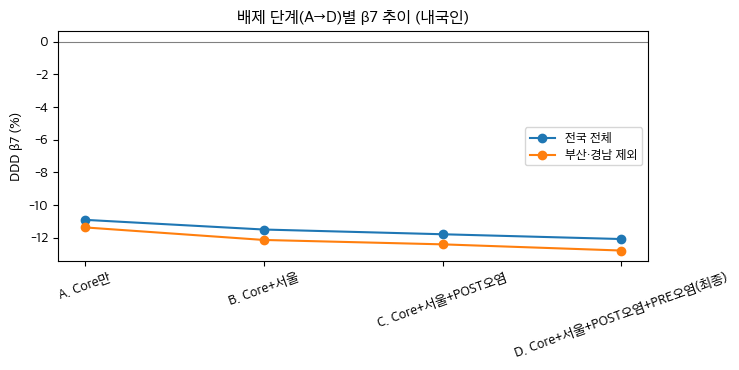

In [11]:
## 5. 시각화 — A→B→C→D 진행에 따른 β7 추이 (내국인, 지리범위별)
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
OUT = Path('../outputs/13_robust_spec'); OUT.mkdir(parents=True, exist_ok=True)   # 그림 저장 폴더
mpl.rcParams['font.family'] = [f for f in ['Apple SD Gothic Neo', 'Malgun Gothic'] if f in {x.name for x in mpl.font_manager.fontManager.ttflist}]   # macOS / Windows 중 설치된 것
mpl.rcParams['axes.unicode_minus'] = False

sub = reg_result.loc['내국인만'].dropna(subset=['β7(%)']).reset_index()
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for geo in sub['대조군범위'].unique():
    s = sub[sub['대조군범위'] == geo]
    ax.plot(s['명세'], s['β7(%)'], marker='o', label=geo)
ax.axhline(0, color='grey', lw=0.8)
ax.set_ylabel('DDD β7 (%)'); ax.set_title('배제 단계(A→D)별 β7 추이 (내국인)')
ax.tick_params(axis='x', rotation=20); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(OUT / '05_beta7_by_stage.png', dpi=200, bbox_inches='tight'); plt.show()